### [KNN 분류 성능평가지표 실습 - Iris 데이터셋]

- **KNN 분류 모델을 만들고, 분류 모델의 대표 성능평가지표 확인** 

- **학습 목표**
    - KNN 분류 모델을 학습한다.
    - Accuracy, Precision, Recall, F1-score를 계산한다.
    - Confusion Matrix를 해석한다.
    - Classification Report를 읽는 방법을 이해한다.

- **Iris 데이터셋**
    - 붓꽃 품종을 분류하는 대표적인 다중분류 데이터셋
    - 클래스 : setosa, versicolor, virginica

- **[0] 모듈 로딩**

In [7]:
## 데이터 관련
import pandas as pd
import numpy as np

## 시각화 관련
import matplotlib.pyplot as plt
import seaborn as sns

## ML 데이터셋 관련
from sklearn.model_selection import train_test_split

## ML 데이터 전처리 관련
from sklearn.preprocessing import StandardScaler
## ML 모델 관련
from sklearn.neighbors import KNeighborsClassifier
## ML 모델 성능지표 관련
from sklearn.metrics import accuracy_score,  precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

- **[1] 데이터 준비**

In [9]:
## 데이터 설정
DATA_FILE = '../Data/Numbers/iris.csv'

## 데이터 로딩 
irisDF = pd.read_csv(DATA_FILE)

In [15]:
## 기본 정보 확인
irisDF.info()
display(irisDF.head(3))

## 품종별 데이터 개수 확인
display( irisDF["variety"].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa


variety
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

In [29]:
## variety 타겟 컬럼 str => category 형변환
irisDF['variety'] = irisDF['variety'].astype('category')

display(irisDF.dtypes)

sepal.length     float64
sepal.width      float64
petal.length     float64
petal.width      float64
variety         category
dtype: object

In [30]:
## [해석] -------------------------------------------------
## - 클래스별 균형 잡힌 데이터셋
## - 수치값 스케일링
## --------------------------------------------------------

- **[2] 학습 데이터/ 테스트 데이터 준비**

In [31]:
## 피쳐와 타겟 분리
featureDF = irisDF[irisDF.columns[:-1]]
targetSR  = irisDF[irisDF.columns[-1]]

In [32]:
## 품종 클래스 비율 유지하면서 분리
X_train, X_test, y_train, y_test = train_test_split(
    featureDF,                  # 입력 데이터 2D
    targetSR,                   # 정답 데이터 1D
    test_size=0.2,              # 전체 데이터 중 20%를 테스트 데이터로 사용
    random_state=42,            # 실행할 때마다 같은 결과가 나오도록 난수 시드를 고정
    stratify=targetSR           # 품종 비율이 학습/테스트 데이터 유지되도록 설정
)

In [33]:
## 학습용, 테스트용 데이터셋 체크
print(f"[TRAIN] X_train shape: {X_train.shape}  y_train shape: {y_train.shape}")
print(f"품종 개수: {y_train.value_counts()}\n")

print(f"[TEST] X_test shape: {X_test.shape}  y_test shape: {y_test.shape}")
print(f"품종 개수: {y_test.value_counts()}\n")

[TRAIN] X_train shape: (120, 4)  y_train shape: (120,)
품종 개수: variety
Setosa        40
Versicolor    40
Virginica     40
Name: count, dtype: int64

[TEST] X_test shape: (30, 4)  y_test shape: (30,)
품종 개수: variety
Setosa        10
Versicolor    10
Virginica     10
Name: count, dtype: int64



- **[3]전처리 - 스케일링**
    * KNN은 거리 기반 알고리즘 => 각 속성의 값 범위가 다르면 거리 계산에 영향을 줄 수 있음
    
    * ★주의★
        - 스케일러는 학습 데이터셋으로 생성
        - fit_transform(): 학습 데이터에만 사용
        - transform() : 테스트 데이터만 사용
        - 테스트 데이터로 스케일러를 다시 학습하면 데이터 누수가 발생

In [34]:
## --------------------------------------------------------
## 수치 피쳐 컬럼 : 수치값 범위 일치
## --------------------------------------------------------
## StandardScaler 객체를 생성
scaler = StandardScaler()

## 학습 데이터의 평균과 표준편차를 계산하고 학습 데이터를 변환
X_train_scaled = scaler.fit_transform(X_train)

## 학습 데이터에서 계산한 평균과 표준편차로 테스트 데이터를 변환
X_test_scaled = scaler.transform(X_test)

- **[4]KNN 모델 학습**

In [35]:
## 모델 인스턴스 생성
kModel = KNeighborsClassifier(n_neighbors=5)

## 스케일링된 학습 데이터로 KNN 모델 학습
kModel.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['Setosa','Versicolor','Virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [36]:

## 스케일링된 테스트 데이터로 품종을 예측
y_pred = kModel.predict(X_test_scaled)

## 실제값과 예측값을 비교 DataFrame
resultDF = pd.DataFrame({ "y_test": y_test,  "y_pred": y_pred })       
resultDF.head(10)

,y_test,y_pred
38,Setosa,Setosa
127,Virginica,Virginica
57,Versicolor,Versicolor
93,Versicolor,Versicolor
42,Setosa,Setosa
56,Versicolor,Versicolor
22,Setosa,Setosa
20,Setosa,Setosa
147,Virginica,Virginica
84,Versicolor,Versicolor


- **[5]성능평가지표 계산**
    - **성능평가**
        * Accuracy 정확도 : 전체 데이터 중에서 모델이 맞게 예측한 비율
        * Precision 정밀도 : 모델이 특정 클래스로 예측한 것 중 실제로 맞은 비율
        * Recall 재현율 : 실제 특정 클래스 데이터 중 모델이 제대로 찾아낸 비율
        * F1-score : Precision과 Recall의 균형을 나타내는 지표

        * ★ 데이터 불균형한 경우 
        * => Accuracy만 보는 것보다 Precision, Recall, F1-score 함께 평가
       
    - **다중분류**
        * precision_score, recall_score, f1_score 사용 시 => average 옵션
        * average="macro"
        * macro => 각 클래스를 동일한 비중으로 평균. 데이터 수가 적은 클래스도 공평하게 반영

In [37]:
## 정확도 / macro 평균 정밀도 /macro 평균 재현율 / macro 평균 F1-score 
accuracy        = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro    = recall_score(y_test, y_pred, average="macro")
f1_macro        = f1_score(y_test, y_pred, average="macro")

## 성능 평가 결과 출력
print("------------------------------------")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision macro: {precision_macro:.4f}")
print(f"Recall macro   : {recall_macro:.4f}")
print(f"F1-score macro : {f1_macro:.4f}")
print("------------------------------------")

------------------------------------
Accuracy       : 0.9333
Precision macro: 0.9444
Recall macro   : 0.9333
F1-score macro : 0.9327
------------------------------------


- **[6]Confusion Matrix 혼동행렬**
- 실제값과 예측값을 비교하는 표
    - 행: 실제 클래스
    - 열: 예측 클래스
    - 대각선: 맞게 예측한 개수
    - 대각선이 아닌 값: 잘못 예측한 개수

In [40]:
## 실제값과 예측값으로 혼동행렬을 생성
cm = confusion_matrix(y_test, y_pred)

## 혼동행렬을 DataFrame으로 변환하여 행/열 이름을 품종명으로 표시
target_names = irisDF['variety'].cat.categories
cmDF = pd.DataFrame(cm, index=target_names, columns=target_names)

display(cmDF)

,Setosa,Versicolor,Virginica
Setosa,10,0,0
Versicolor,0,10,0
Virginica,0,2,8


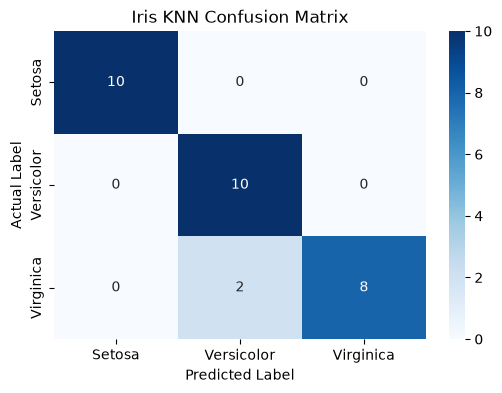

In [ ]:
## 시각화
plt.figure(figsize=(6, 4))

## 혼동행렬을 heatmap 형태로 시각화
sns.heatmap(cmDF, annot=True, fmt="d", cmap="Blues")

plt.title("Iris KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

- **[8]Classification Report**

    - 클래스별 Precision, Recall, F1-score, Support를 한 번에 보여줌
    - `precision`: 해당 클래스로 예측한 것 중 맞은 비율
    - `recall`: 실제 해당 클래스를 얼마나 잘 찾았는지
    - `f1-score`: precision과 recall의 균형
    - `support`: 실제 데이터 개수

In [43]:
## 클래스별 성능평가지표 출력
report = classification_report(
    y_test,                    # 실제 정답
    y_pred,                    # 모델 예측값
    target_names=target_names  # 클래스 번호 대신 품종명을 출력
)

print(report)

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.83      1.00      0.91        10
   Virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

